<a href="https://colab.research.google.com/github/springboardmentor12458j/LiveMeetingSummarize/blob/Nikhitha/Video%20to%20Audio%20Extraction%20and%20Audio%20Signal%20Visualization%20using%20Python%20(Google%20Colab).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install librosa moviepy matplotlib


In [6]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from moviepy.editor import VideoFileClip
from google.colab import files


In [7]:
uploaded = files.upload()   # Upload any .mp4 video
video_path = list(uploaded.keys())[0]
print("Uploaded video:", video_path)


Saving Devasena.mp4 to Devasena.mp4
Uploaded video: Devasena.mp4


In [8]:
video_clip = VideoFileClip(video_path)
audio_path = "extracted_audio.wav"
video_clip.audio.write_audiofile(audio_path)


MoviePy - Writing audio in extracted_audio.wav


MoviePy - Done.


In [9]:
audio, sr = librosa.load(audio_path)
print("Sampling rate:", sr)


Sampling rate: 22050


In [10]:
amplitude = np.abs(audio)


In [11]:
n_fft = 2048
hop_length = 512

stft = np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=hop_length))


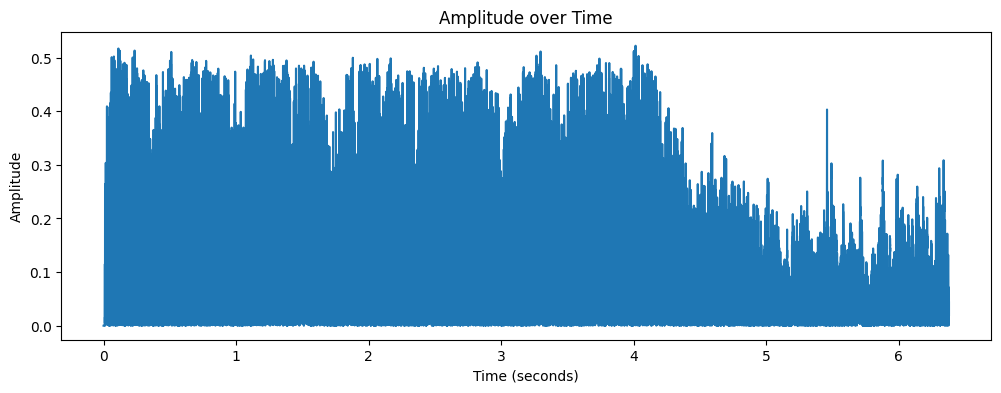

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(audio)) / sr, amplitude)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Amplitude over Time")
plt.show()


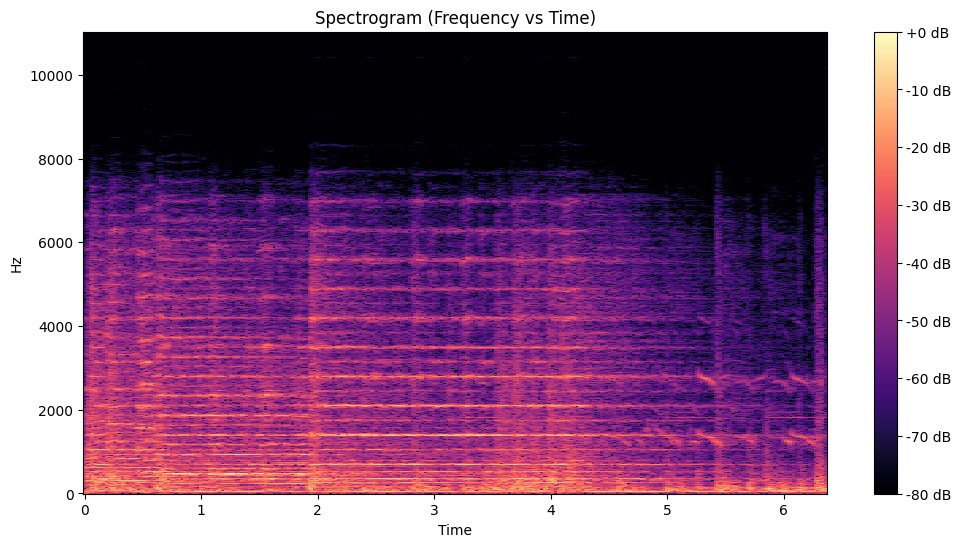

In [13]:
S_db = librosa.amplitude_to_db(stft, ref=np.max)

plt.figure(figsize=(12, 6))
librosa.display.specshow(
    S_db,
    sr=sr,
    hop_length=hop_length,
    x_axis='time',
    y_axis='hz'
)
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram (Frequency vs Time)")
plt.show()
